In [ ]:
from neuromodes.eigen import EigenSolver, project_emodes
from lapy.plot import plot_tet_mesh
from nilearn.plotting import plot_stat_map
import matplotlib.pyplot as plt
import numpy as np

nifti = 'C:/Users/ipop0003/neuromodes/neuromodes/data/hcp_tha-lh_thr25.nii.gz'

solver = EigenSolver(nifti).solve(100)

TetMesh with regular Laplace
Solver: spsolve (LU decomposition) ...


In [2]:
plot_tet_mesh(solver.geometry, vfunc=solver.emodes[:, 1], plot_edges=True)

Mesh is oriented, nothing to do
Found 2104 triangles on boundary.


Number of NaNs: 582
Number of Infs: 0


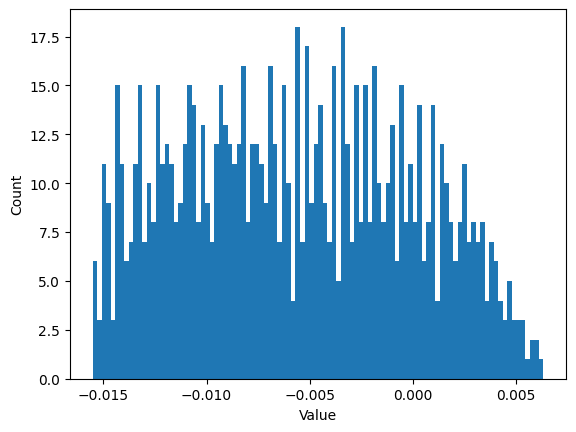

In [3]:
# project eigenmodes into volume space
emodes_vox = project_emodes(nifti, solver.emodes[:, [1]], solver.geometry)

# check for nans and infs in mask
data = emodes_vox.get_fdata()
data = data[data != 0]
print('Number of NaNs:', np.isnan(data).sum())
print('Number of Infs:', np.isinf(data).sum())

# Plot distribution
plt.hist(data.flatten(), bins=100)
plt.xlabel('Value')
plt.ylabel('Count')
plt.show()

C:\Users\ipop0003\AppData\Local\Temp\ipykernel_21204\3806300854.py:1: UserWarning:

Non-finite values detected. These values will be replaced with zeros.



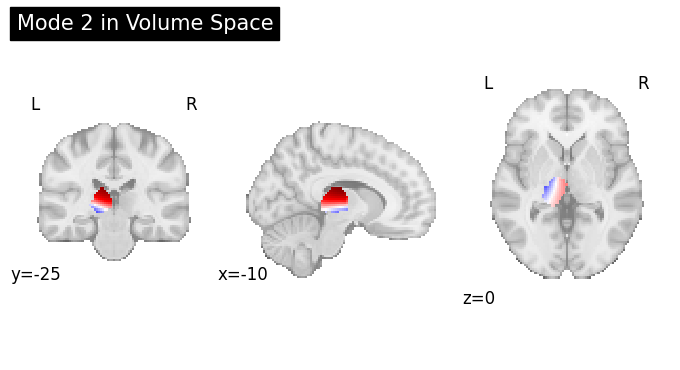

In [4]:

plot_stat_map(emodes_vox, cut_coords=(-10, -25, 0), title='Mode 2 in Volume Space', cmap='seismic_r', draw_cross=False, colorbar=False)